# BSRNN workbook
The aim for this workbook is to start designing the components of the BSRNN from the 'High Fidelity Speech Enhancement BSRNN' paper.

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import soundfile as sf
import time
from collections import defaultdict
import math
import yaml

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [86]:
# Load configs
def load_config(model_yaml="bsrnn_baseline.yaml", repo_root=None):
    root = Path(repo_root or Path.cwd())
    while not (root / "CLAUDE.md").exists() and root != root.parent:
        root = root.parent
    cfgs = root / "experiments" / "configs"
    
    model = yaml.safe_load((cfgs / model_yaml).read_text())
    gen   = yaml.safe_load((cfgs / "generator.yaml").read_text())
    
    # Single source of truth: the rate the data was rendered at.
    model["sample_rate"] = gen["sample_rate"]
    return model, root

cfg, ROOT = load_config()
sr     = cfg["sample_rate"]
n_fft  = cfg["model"]["stft"]["n_fft"]
hop    = cfg["model"]["stft"]["hop"]
k      = cfg["model"]["lookahead_frames"]
lstm_hidden_dim = cfg["model"]["separator"]["lstm_hidden"]




In [87]:
class TrialDataset(torch.utils.data.Dataset):
    def __init__(self, manifest_csv, data_root, split, chunk_s, sample_rate, seed, random_crop=True):
        self.data_root    = Path(data_root)
        self.split        = split                   
        self.chunk_s      = chunk_s        
        self.sample_rate  = sample_rate
        self.seed         = seed
        self.random_crop  = random_crop
        self.chunk_frames = int(chunk_s * sample_rate)
        self.epoch        = 0                       

        self.manifest_df = pd.read_csv(manifest_csv)

    def __len__(self):
        return len(self.manifest_df)

    def __getitem__(self, idx):
        # there are a couple of things that I need to get:
        # 1. the mixture audio
        # 2. the target speaker audio
        # 3. the enrollment audio

        # Then there are a few things that are not necessary but are useful:
        # 1. the meta data
        # 2. the trial_id
        # 3. the crop absent

        row = self.manifest_df.iloc[idx]
        trial_directory = self.data_root / "rendered" / self.split / row["trial_id"]
        mixture_directory = trial_directory / "mixture.wav"
        number_of_frames = sf.info(str(mixture_directory)).frames

        start_offset = self._crop_offset_start(idx, number_of_frames)
        mixture_audio = self._read_in_wav(mixture_directory, start=start_offset, frames=self.chunk_frames)
        target_audio = self._read_in_wav(trial_directory / "target.wav", start=start_offset, frames=self.chunk_frames)
        enrollment_audio = self._read_in_wav(trial_directory / "enrollment.wav")

        crop_absent = bool(target_audio.abs().max() == 0)
        return {
            "mixture": mixture_audio,
            "target": target_audio,
            "enrollment": enrollment_audio,
            "crop_absent": crop_absent,
            "trial_id": str(row["trial_id"]),
            "meta": {
                "condition":        str(row["condition"]),
                "clip_absent":      bool(row["target_absent"]),
                "sir_db":           float(row["sir_db"]),
                "snr_db":           float(row["snr_db"]),
                "overlap_achieved": float(row["overlap_achieved"]),
                "regime":           str(row["regime"]),
                "same_gender":      float(row["same_gender"]),
            },
        }


    def _read_in_wav(self, path, start=0, frames=-1):
        # Read in a wav file and return a torch tensor of shape (frames,)
        with sf.SoundFile(str(path)) as f:
            assert f.samplerate == self.sample_rate, f"Sample rate mismatch: {f.samplerate} != {self.sample_rate}"
            assert f.channels == 1, f"Channel mismatch: {f.channels} != 1"

            if start > 0:
                f.seek(start)
            
            x = f.read(frames, dtype='float32', always_2d=False)

        return torch.from_numpy(np.ascontiguousarray(x))

    def _crop_offset_start(self, idx, n_frames):
        # This is used to determine the starting point of the crop for the audio. It is important to note that this is only used for the mixture and target audio, not the enrollment audio. The enrollment audio is always read in full.

        max_start = n_frames - self.chunk_frames
        assert max_start >= 0, f"clip {n_frames} shorter than chunk {self.chunk_frames}"

        epoch = self.epoch if self.random_crop else 0
        rng = np.random.default_rng((self.seed, epoch, idx))
        return int(rng.integers(0, max_start + 1))

    def set_epoch(self, epoch):
        # call this at the top of each training epoch to ensure that the random cropping is consistent across all samples in the dataset. This is important for reproducibility and to ensure that the model sees the same data in each epoch.
        self.epoch = epoch


In [88]:
smoke_train_dataset = TrialDataset(
    manifest_csv="./../../data/manifests/smoke_train.csv",
    data_root="./../../data",
    split="smoke_train",
    chunk_s=4.0, # follow CARTSE
    sample_rate=16000,
    seed=42
)

smoke_valid_dataset = TrialDataset(
    manifest_csv="./../../data/manifests/smoke_val.csv",
    data_root="./../../data",
    split="smoke_val",
    chunk_s=4.0, # follow CARTSE
    sample_rate=16000,
    seed=42,
    random_crop=False,
)

smoke_train_loader = torch.utils.data.DataLoader(
    smoke_train_dataset,
    batch_size=12, # Follow CARTSE
    shuffle=True,
    num_workers=4
)

smoke_valid_loader = torch.utils.data.DataLoader(
    smoke_valid_dataset,
    batch_size=12, # Follow CARTSE
    shuffle=False,
    num_workers=4
)

In [89]:
# Example of how to use the dataset and dataloader
for batch in smoke_train_loader:
    mixture = batch["mixture"]
    target = batch["target"]
    enrollment = batch["enrollment"]
    crop_absent = batch["crop_absent"]
    trial_id = batch["trial_id"]
    meta = batch["meta"]

    print(f"Mixture shape: {mixture.shape}")
    print(f"Target shape: {target.shape}")
    print(f"Enrollment shape: {enrollment.shape}")
    print(f"Crop absent: {crop_absent}")
    print(f"Trial ID: {trial_id}")
    print(f"Meta: {meta}")
    break  # Just process one batch for demonstration 

Mixture shape: torch.Size([12, 64000])
Target shape: torch.Size([12, 64000])
Enrollment shape: torch.Size([12, 80000])
Crop absent: tensor([False, False, False, False, False, False, False,  True,  True, False,
        False, False])
Trial ID: ['smoke_train-42-000048', 'smoke_train-42-000010', 'smoke_train-42-000038', 'smoke_train-42-000049', 'smoke_train-42-000011', 'smoke_train-42-000031', 'smoke_train-42-000014', 'smoke_train-42-000039', 'smoke_train-42-000017', 'smoke_train-42-000030', 'smoke_train-42-000044', 'smoke_train-42-000012']
Meta: {'condition': ['both', 'target_only', 'target_only', 'target_only', 'both', 'target_only', 'both', 'noise_only', 'interferer_only', 'both', 'both', 'target_only'], 'clip_absent': tensor([False, False, False, False, False, False, False,  True,  True, False,
        False, False]), 'sir_db': tensor([ 8.0300,     nan,     nan,     nan,  7.3200,     nan,  8.8500,     nan,
            nan,  3.6400, 13.7600,     nan], dtype=torch.float64), 'snr_db': te

In [90]:
# Need to just validate that the crops that I make still align to the split of data with the 50% both, 25% target only, 20% interfere only, and 5% noise only
def measure_empty_crops(ds, n_trials=3000, epochs=3, sample_seed=0):
    """Fraction of crops that contain no target speech, per epoch and condition.
    
    Reuses the dataset's own crop-offset RNG so the offsets are exactly the ones
    training will draw. Reads only target.wav — mixture and enrollment are not
    needed to answer this.
    """
    rng = np.random.default_rng(sample_seed)
    idxs = rng.choice(len(ds), size=min(n_trials, len(ds)), replace=False)
    
    n_frames_cache = {}          # frames don't change across epochs
    rows = []
    t0 = time.perf_counter()
    
    for ep in range(epochs):
        ds.set_epoch(ep)
        for i in idxs:
            i = int(i)
            r = ds.manifest_df.iloc[i]
            tdir = ds.data_root / "rendered" / ds.split / r["trial_id"]
            
            if i not in n_frames_cache:
                n_frames_cache[i] = sf.info(str(tdir / "mixture.wav")).frames
            start = ds._crop_offset_start(i, n_frames_cache[i])
            
            tgt = ds._read_in_wav(tdir / "target.wav",
                                start=start, frames=ds.chunk_frames)
                                 
            rows.append({         
                "epoch":       ep,
                "condition":   r["condition"],
                "clip_absent": bool(r["target_absent"]),
                "crop_absent": bool(tgt.abs().max() == 0),
                "activity":    float(r["target_activity"]),
            })  
              
    print(f"{len(rows)} crops in {time.perf_counter()-t0:.1f}s")
    return pd.DataFrame(rows)                    


In [91]:
# train_dataset = TrialDataset(
#     manifest_csv="./../../data/manifests/train.csv",
#     data_root="./../../data",
#     split="train",
#     chunk_s=4.0,
#     sample_rate=16000,
#     seed=42,
#     random_crop=True,
# )

# df = measure_empty_crops(train_dataset, n_trials=3000, epochs=3)

# designed  = df["clip_absent"].mean()      # what the generator was configured for
# effective = df["crop_absent"].mean()      # what the model actually trains on
# present   = df[~df["clip_absent"]]
# leakage   = present["crop_absent"].mean()

# print(f"designed  absent rate (clip level) : {designed:.3f}")
# print(f"effective absent rate (crop level) : {effective:.3f}")
# print(f"drift                              : {effective - designed:+.3f}")
# print(f"leakage (present trial -> silent crop): {leakage:.3f}")

# print("\nleakage by condition:")
# print(present.groupby("condition")["crop_absent"].agg(["mean", "count"]))

# print("\nleakage by target_activity band:")
# banded = present.assign(band=pd.cut(present["activity"], [0, .2, .3, .4, .5, .6, .8]))
# print(banded.groupby("band", observed=True)["crop_absent"].agg(["mean", "count"]))

# print("\nper-epoch effective rate (should be stable):")
# print(df.groupby("epoch")["crop_absent"].mean())


## 1. Create the STFT

In [92]:
class STFT(nn.Module):
    def __init__(self, n_fft=512, hop_length=128, sample_rate=16000):
        super().__init__()
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.sample_rate = sample_rate
        self.padding = n_fft - hop_length
        self.register_buffer("window", torch.hann_window(n_fft), persistent=False)
    
          
    def latency_ms(self, lookahead_frames=0):
        """Algorithmic latency. Convention: window fill + emit hop + lookahead.
        State the convention when you quote it -- CARTSE counts window - hop
        instead, so their 24 ms and our 40 ms describe the same framing."""
        samples = self.n_fft + self.hop_length + lookahead_frames * self.hop_length
        return 1000 * samples / self.sample_rate 

    def _n_frames(self, T):
      # +2*padding: the tail needs the same ramp-out room the head gets, or the
      # final samples land where the OLA envelope has decayed to ~0.
      return math.ceil((T + 2 * self.padding - self.n_fft) / self.hop_length) + 1
 
    # (B, T) -> (B, F, N) complex
    def forward(self, x):                        
        T = x.shape[-1]
        n_frames = self._n_frames(T)
        right = (n_frames - 1) * self.hop_length + self.n_fft - (T + self.padding)
        xp = F.pad(x, (self.padding, right))
        return torch.stft(xp, self.n_fft, self.hop_length, self.n_fft,
                            self.window, center=False, return_complex=True)

    # (B, F, N) complex -> (B, length)                  
    def inverse(self, X, length):              
        frames = torch.fft.irfft(X, n=self.n_fft, dim=1) * self.window[None, :, None]
        B, _, N = frames.shape
        total = (N - 1) * self.hop_length + self.n_fft
        fold = lambda t: F.fold(t, (1, total), (1, self.n_fft), stride=(1, self.hop_length))
        
        out = fold(frames).view(B, total)
        env = fold(self.window.pow(2)[None, :, None].expand(1, -1, N)).view(total)
        return (out / env.clamp_min(1e-11))[:, self.padding:self.padding + length]





In [93]:
# example test STFT
f = STFT()
x = torch.randn(2, 64000)
print("round-trip:", (f.inverse(f(x), 64000) - x).abs().max().item())   # expect ~7e-7
print("latency k=0:", f.latency_ms(0), "ms   k=16:", f.latency_ms(16), "ms")

round-trip: 9.5367431640625e-07
latency k=0: 40.0 ms   k=16: 168.0 ms


In [94]:
f = STFT()
for T in (64000, 63999, 12345):          # odd lengths matter — 64000 hides padding bugs
    x = torch.randn(2, T)
    err = (f.inverse(f(x), T) - x).abs().max()
    assert err < 1e-5, f"T={T}: {err}"
    print(f"T={T}: {err:.2e}")


T=64000: 9.54e-07
T=63999: 7.15e-07
T=12345: 7.15e-07


## 2. Build the band plan table as a pure function


This is for breaking down the audio mixture into the subbands that will be used in the model. How it works is the mixture audio gets sent to a STFT, which will output a number of bins `n_fft`. I then group these bins according to some plan that I set in the config file.

In [95]:
BAND_PRESETS = {
    # Inherited 16 kHz plan. NOT from Yu et al. (Interspeech 2023) -- that paper
    # specifies 33 subbands (20x200 + 6x500 + 7x2k Hz) for its 48 kHz model.
    # This is the wesep / REAL-TSE baseline's own 16 kHz adaptation, unpublished
    # and unjustified anywhere in the literature. See decisions-m1.md.
    "wesep_16k": [
        {"bandwidth_hz":  100, "count": 15},
        {"bandwidth_hz":  200, "count": 10},
        {"bandwidth_hz":  500, "count":  5},
        {"bandwidth_hz": 2000, "count":  1},
    ],  
     
    # --- control --------------------------------------------------------
    # Equal-width bands. If this matches wesep_16k, non-uniform splitting is
    # doing no work and a large part of the architecture's story is wrong.
    "uniform_32": {"uniform": 32},
    
    # --- the paper's own shape, truncated to our bandwidth ---------------
    # Yu et al. (Interspeech 2023) sec 4.2 specify 20x200 + 6x500 + 7x2k Hz
    # for 48 kHz. Applying the same progression to our 0-8 kHz gives this.
    # The closest thing to a published plan for this architecture.
    "yu_truncated": {"segments": [
        {"bandwidth_hz":  200, "count": 20},   # 0 - 4 kHz
        {"bandwidth_hz":  500, "count":  6},   # 4 - 7 kHz
    ]},                                        # remainder -> 7 - 8 kHz
    
    # --- perceptually motivated -----------------------------------------
    # Bark critical bands (Zwicker, 1961). Band edges are where the auditory
    # system integrates energy and where masking occurs -- a real reason for
    # boundaries to sit where they do, which no other plan here has.
    "bark": {"edges_hz": [0, 100, 200, 300, 400, 510, 630, 770, 920, 1080,
                        1270, 1480, 1720, 2000, 2320, 2700, 3150, 3700,
                        4400, 5300, 6400, 7700, 8000]},
                        
    # --- matched to the downstream model --------------------------------
    # Mel spacing, the filterbank every ASR front-end and our proxy losses
    # actually consume. Argument is project-specific: our objective is what a
    # live model understands, so aligning band structure with the
    # representation that model listens through is a motivation nobody else
    # in this literature has, because nobody else has our metric.
    "mel_32": {"mel": 32},

    # --- task-motivated --------------------------------------------------
    # Maximum resolution across F0 and the first two formants (80-1000 Hz),
    # coarse above. Two-speaker separation leans on resolving harmonic
    # structure; this spends the budget there deliberately.
    "f0_focused": {"segments": [
        {"bandwidth_hz":  100, "count": 10},   # 0 - 1 kHz, finest available
        {"bandwidth_hz":  250, "count": 12},   # 1 - 4 kHz
        {"bandwidth_hz": 1000, "count":  3},   # 4 - 7 kHz
    ]}, 


} 

We need functions for ALL plans, so that we can test them and see if they are actually doing any work. The uniform plan is the control, and the other plans are the experimental conditions. If the uniform plan performs just as well as the other plans, then the non-uniformity is not actually doing any work.

In [96]:
def uniform_plan(n_fft, n_bands):
    """Equal-width bands -- the control that shows non-uniformity does any work."""
    n_bins = n_fft // 2 + 1
    base, extra = divmod(n_bins, n_bands)
    return [base + 1] * extra + [base] * (n_bands - extra)

def _from_segments(sample_rate, n_fft, segments):
    n_bins, hz = n_fft // 2 + 1, sample_rate / n_fft
    widths = []
    for seg in segments:
        w = int(math.floor(seg["bandwidth_hz"] / hz))
        if w < 1:
            raise ValueError(f"{seg['bandwidth_hz']} Hz < one bin ({hz:.2f} Hz)")
        widths.extend([w] * int(seg["count"]))
    remainder = n_bins - sum(widths)
    if remainder < 1:
        raise ValueError(f"segments consume {sum(widths)} of {n_bins} bins")
    widths.append(remainder)
    return widths
    
def _from_edges(sample_rate, n_fft, edges_hz): 
    """Band edges in Hz -> bin counts. Natural form for perceptual scales."""
    n_bins, hz = n_fft // 2 + 1, sample_rate / n_fft
    idx = [int(round(e / hz)) for e in edges_hz]
    idx[0], idx[-1] = 0, n_bins                  # snap to full coverage
    return [b - a for a, b in zip(idx, idx[1:])]

   
def _mel_edges(n_bands, sample_rate):
    to_mel   = lambda f: 2595 * math.log10(1 + f / 700)
    from_mel = lambda m: 700 * (10 ** (m / 2595) - 1)
    top = to_mel(sample_rate / 2)
    return [from_mel(top * i / n_bands) for i in range(n_bands + 1)]

In [97]:
def band_plan(sample_rate, n_fft, spec):
      """Bin counts per band, summing to n_fft // 2 + 1.

      Luo & Yu (TASLP 2023) for band splitting; Yu et al. (Interspeech 2023) for
      the speech adaptation. Neither publishes a 16 kHz table -- decisions-m1.md.
      """
      if isinstance(spec, str):
          spec = BAND_PRESETS[spec]
      if isinstance(spec, list):                   # bare segments list
          spec = {"segments": spec}
      
      if   "segments" in spec: widths = _from_segments(sample_rate, n_fft, spec["segments"])
      elif "edges_hz" in spec: widths = _from_edges(sample_rate, n_fft, spec["edges_hz"])
      elif "uniform"  in spec: widths = uniform_plan(n_fft, spec["uniform"])
      elif "mel"      in spec: widths = _from_edges(sample_rate, n_fft, _mel_edges(spec["mel"], sample_rate))
      else: raise ValueError(f"unknown band spec kind: {list(spec)}")
      
      n_bins = n_fft // 2 + 1
      assert sum(widths) == n_bins, f"{sum(widths)} != {n_bins}"
      assert min(widths) >= 1, f"empty band in {widths}"
      return widths


In [98]:
for name in BAND_PRESETS:
    w = band_plan(16000, 512, name)
    print(f"{name:14s} {len(w):3d} bands  sum={sum(w)}  min={min(w)}  max={max(w)}")


wesep_16k       32 bands  sum=257  min=3  max=64
uniform_32      32 bands  sum=257  min=8  max=9
yu_truncated    27 bands  sum=257  min=6  max=41
bark            22 bands  sum=257  min=3  max=41
mel_32          32 bands  sum=257  min=2  max=22
f0_focused      26 bands  sum=257  min=3  max=35


In [99]:
def describe_plan(widths, sample_rate, n_fft):
    hz, lo = sample_rate / n_fft, 0
    for i, w in enumerate(widths):
        print(f"band {i:2d}  bins {lo:3d}-{lo+w-1:3d} ({w:3d})  "
            f"{lo*hz:7.1f} - {(lo+w)*hz:7.1f} Hz")
        lo += w
        
widths = band_plan(16000, 512, "wesep_16k")
print(len(widths), "bands, sum =", sum(widths))     # expect 32 bands, sum 257
describe_plan(widths, 16000, 512)




32 bands, sum = 257
band  0  bins   0-  2 (  3)      0.0 -    93.8 Hz
band  1  bins   3-  5 (  3)     93.8 -   187.5 Hz
band  2  bins   6-  8 (  3)    187.5 -   281.2 Hz
band  3  bins   9- 11 (  3)    281.2 -   375.0 Hz
band  4  bins  12- 14 (  3)    375.0 -   468.8 Hz
band  5  bins  15- 17 (  3)    468.8 -   562.5 Hz
band  6  bins  18- 20 (  3)    562.5 -   656.2 Hz
band  7  bins  21- 23 (  3)    656.2 -   750.0 Hz
band  8  bins  24- 26 (  3)    750.0 -   843.8 Hz
band  9  bins  27- 29 (  3)    843.8 -   937.5 Hz
band 10  bins  30- 32 (  3)    937.5 -  1031.2 Hz
band 11  bins  33- 35 (  3)   1031.2 -  1125.0 Hz
band 12  bins  36- 38 (  3)   1125.0 -  1218.8 Hz
band 13  bins  39- 41 (  3)   1218.8 -  1312.5 Hz
band 14  bins  42- 44 (  3)   1312.5 -  1406.2 Hz
band 15  bins  45- 50 (  6)   1406.2 -  1593.8 Hz
band 16  bins  51- 56 (  6)   1593.8 -  1781.2 Hz
band 17  bins  57- 62 (  6)   1781.2 -  1968.8 Hz
band 18  bins  63- 68 (  6)   1968.8 -  2156.2 Hz
band 19  bins  69- 74 (  6)   

In [100]:
assert band_plan(16000, 512, "wesep_16k") == [3]*15 + [6]*10 + [16]*5 + [64] + [8]
assert sum(uniform_plan(512, 32)) == 257
assert sum(band_plan(16000, 1024, "wesep_16k")) == 513 

In [101]:
widths = band_plan(sr, n_fft, cfg["model"]["bands"]["plan"])
stft   = STFT(n_fft=n_fft, hop_length=hop, sample_rate=sr)

print(f"{len(widths)} bands, {sum(widths)} bins, latency {stft.latency_ms(k)} ms")

32 bands, 257 bins, latency 40.0 ms


In [102]:
def plot_band_plan(X, widths, sample_rate, n_fft, hop, name="", max_s=4.0):
    """X: (F, N) complex spectrogram for one clip."""
    db = 20 * np.log10(X.abs().cpu().numpy() + 1e-8)
    keep = min(db.shape[1], int(max_s * sample_rate / hop))
    db, dur = db[:, :keep], keep * hop / sample_rate
    nyq = sample_rate / 2
    
    edges = np.minimum(np.cumsum([0] + list(widths)) * (sample_rate / n_fft), nyq)
    centres, bw = (edges[:-1] + edges[1:]) / 2, np.diff(edges)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True,
                                    gridspec_kw={"width_ratios": [3, 1]})
    ax1.imshow(db, origin="lower", aspect="auto", extent=[0, dur, 0, nyq],
                cmap="magma", vmin=db.max() - 80, vmax=db.max())
    for e in edges[1:-1]:
        ax1.axhline(e, color="cyan", lw=0.6, alpha=0.7)
    ax1.set_xlabel("time (s)"); ax1.set_ylabel("frequency (Hz)")
    ax1.set_title(f"{name} — {len(widths)} bands over {n_fft//2+1} bins")
    
    ax2.barh(centres, bw, height=bw * 0.85, color="steelblue")
    ax2.set_xlabel("band width (Hz)"); ax2.set_title("resolution")
    plt.tight_layout()
    return fig



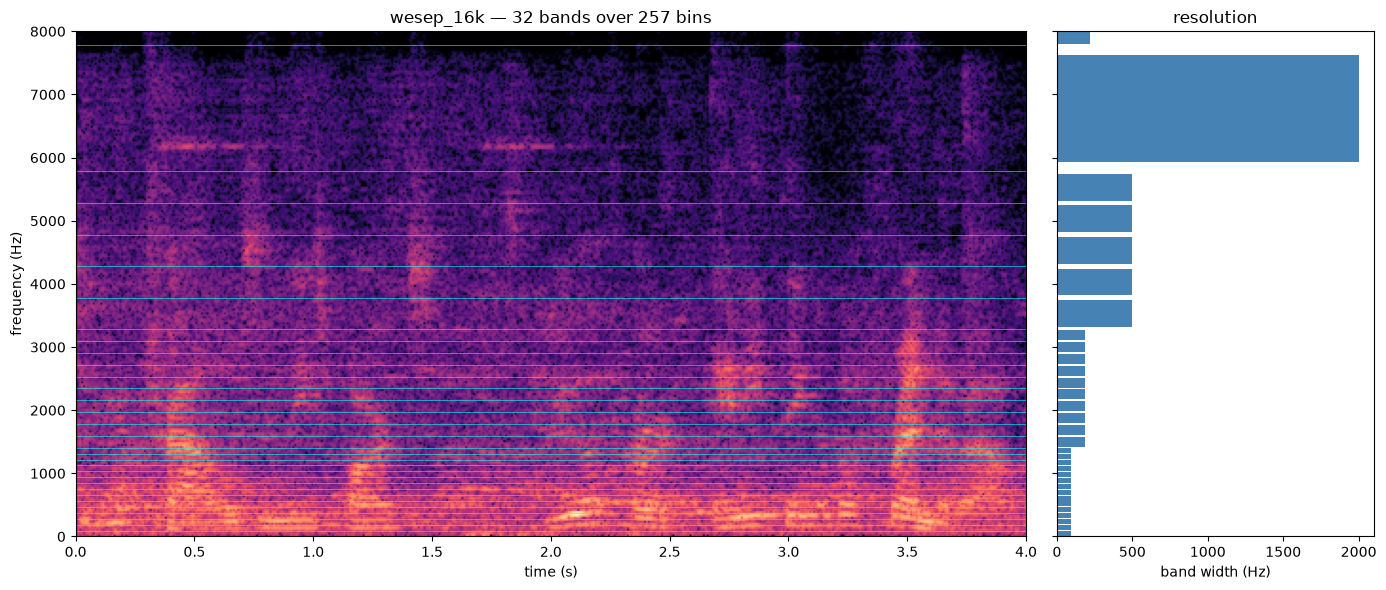

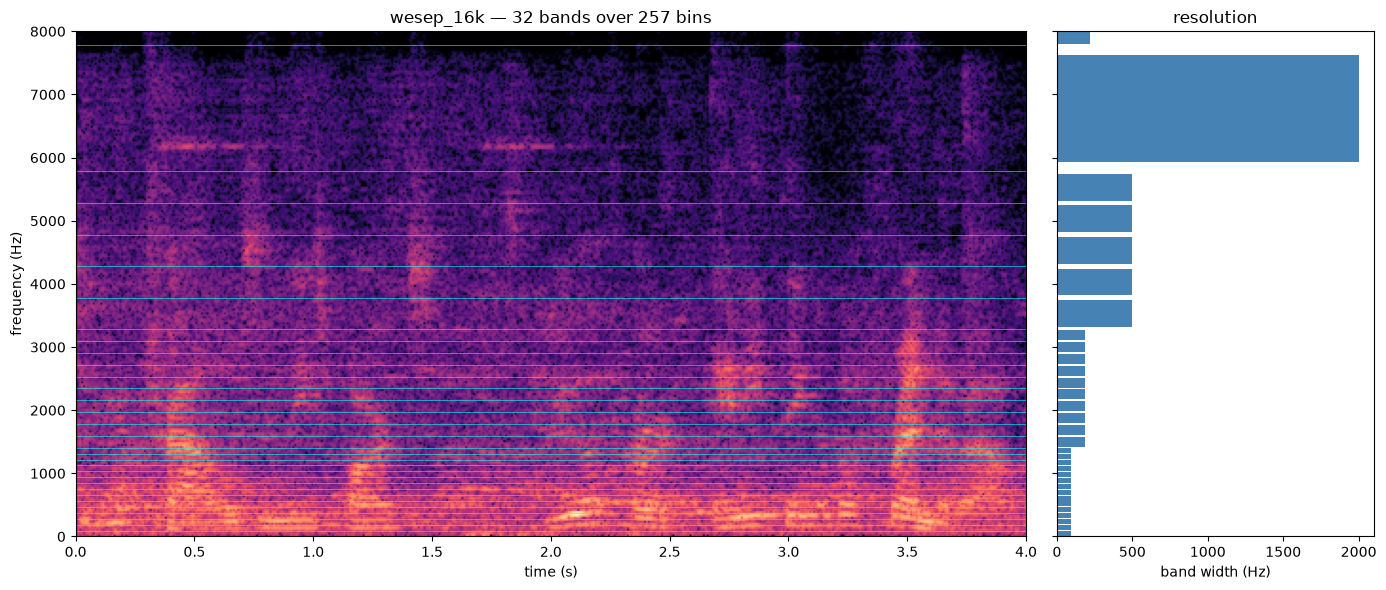

In [103]:
batch = next(iter(smoke_train_loader))
X = stft(batch["mixture"][0:1])[0]
plot_band_plan(X, band_plan(sr, n_fft, "wesep_16k"), sr, n_fft, hop, "wesep_16k")

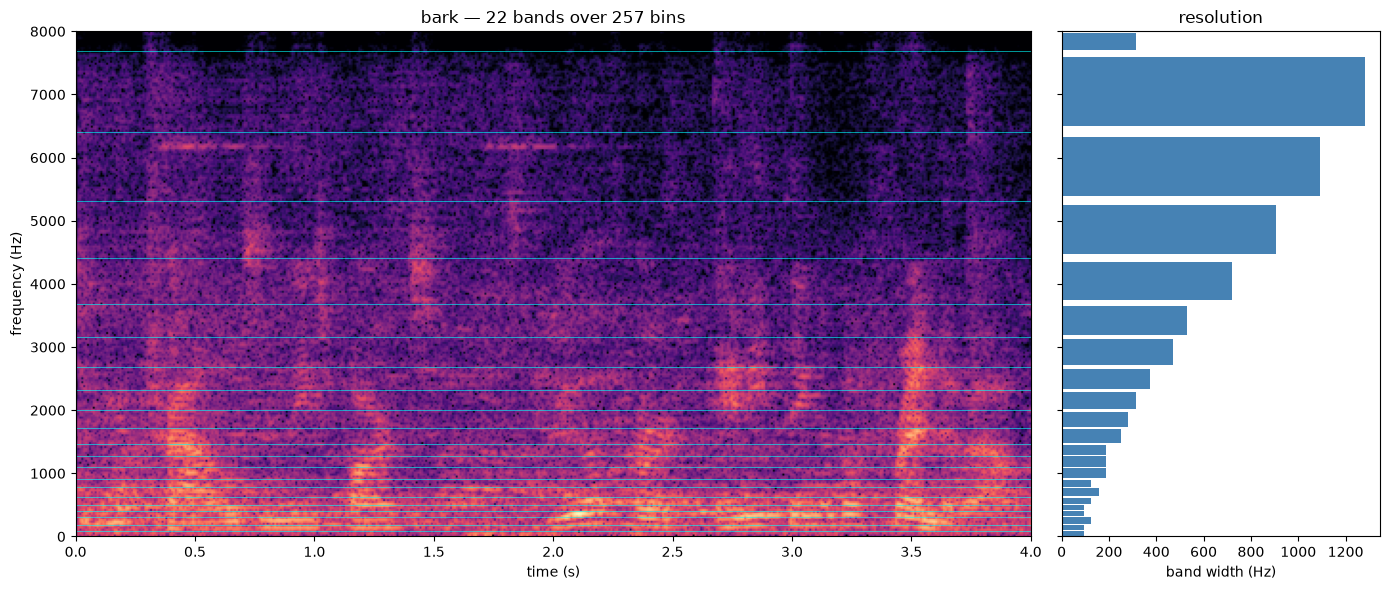

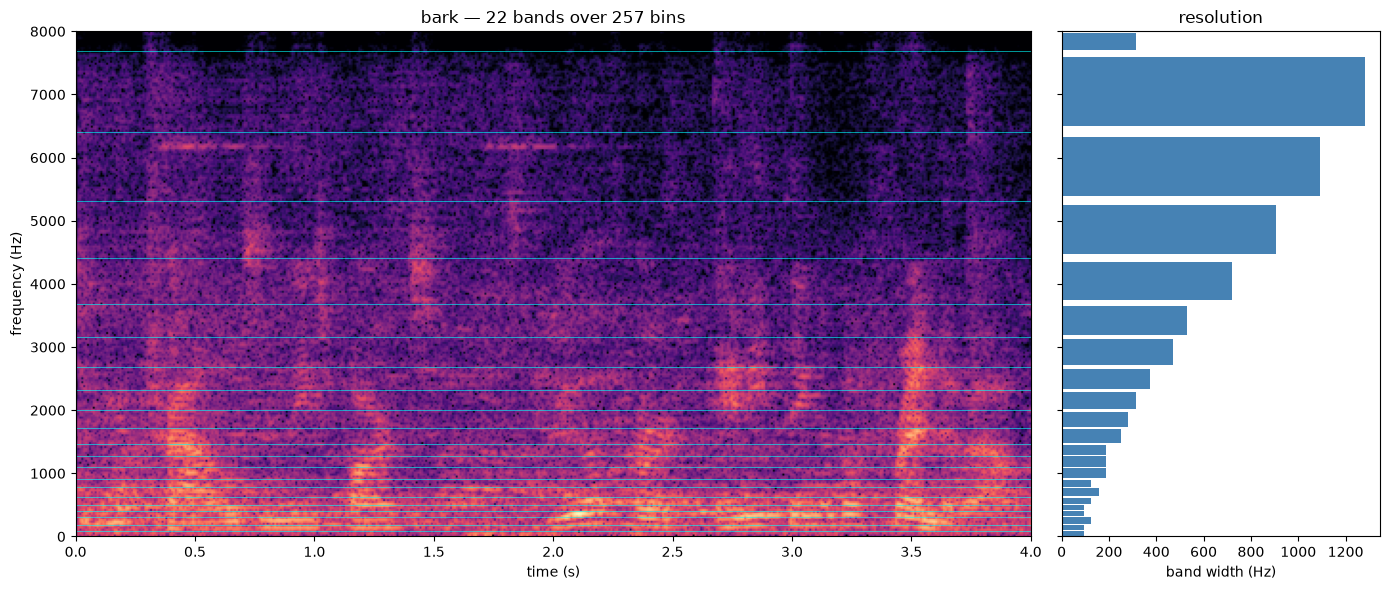

In [104]:
plot_band_plan(X, band_plan(sr, n_fft, "bark"), sr, n_fft, hop, "bark")

## 3. Build the Band Split
Need to slice the (B, C, F, T) into 32 band per band tensors using the widths that I built above. Needs to handle the complex spectrogram which is used for the mask multiply and then the real/imaginary stacked versions.
RMB:
- `B`: Batch-> How many clips we process at once which currently is set to 12
- `C`: Channels -> The feature axis which is set to 2. Will be 3 when we have TF-Map
- `F`: Frequency bins -> 257, the number of bins produced by the STFT
- `T`: Time frames -> 503 calculated using the 4s chunks

Why you split the same spectrogram twice

  This is the part that looks redundant and isn't. Your STFT produces one complex tensor (B, F, T). You need it in two forms:

  (B, 257, T) complex        → split → 32 bands → KEPT ASIDE
                                                  for the mask multiply at the end
                                                 
  (B, 2, 257, T) real/imag   → split → 32 bands → FED TO THE NETWORK
                                                  (SubbandNorm projects each to 128)


Note that due to the different widths we cannot stack these tensors yet. That is what the  SubbandNorm layer will do to project every band to a shared dimensionality. The SubbandNorm layer will be used in the model to project every band to a shared dimensionality, allowing for stacking and further processing.

In [105]:
class BandSplit(nn.Module):
    """ 
    Slice and dice a spectrogram along frequency into per band tensors. 
    
    I will be following the code from  Luo & Yu, "Music Source Separation with Band-Split RNN", TASLP 2023.
    """

    def __init__(self, band_widths):
        super().__init__()
        self.band_widths = list(band_widths) # remember that we have many bands, and each band has a different width in terms of the number of frequency bins.
        self.offsets = np.cumsum([0] + self.band_widths).tolist() # offsets for each band, to slice the spectrogram into bands

    
    def forward(self, spec):
        """
        (B, F, T) complex    -> list of (B, BW, T) complex
        (B, C, F, T) real    -> list of (B, C, BW, T) real
        """
        assert spec.dim() in (3, 4), f"expected 3D or 4D, got {spec.dim()}D"
        assert spec.shape[-2] == self.offsets[-1],  f"{spec.shape[-2]} bins but band plan covers {self.offsets[-1]}"
        return [spec.narrow(-2, lo, w) for lo, w in zip(self.offsets[:-1], self.band_widths)]


In [106]:
widths = band_plan(sr, n_fft, "wesep_16k")
bs = BandSplit(widths)

X = torch.randn(12, 257, 503, dtype=torch.complex64)      
bands = bs(X)
assert len(bands) == len(widths) == 32
assert [b.shape[-2] for b in bands] == widths
assert torch.equal(torch.cat(bands, dim=-2), X)           

Xri = torch.randn(12, 2, 257, 503)                        
assert torch.equal(torch.cat(bs(Xri), dim=-2), Xri)

try:                                                      
    bs(torch.randn(12, 2, 513, 503))
except AssertionError as e:
    
    print("guard OK:", e)


guard OK: 513 bins but band plan covers 257


## 4. Per-Band Normalization
This module is used to project every band to a shared dimensionality, allowing for stacking and further processing. Each band needs to receive its own normalisation and its own FC. 

In [107]:
class ChannelWiseLayerNorm(nn.Module):
    """LayerNorm over the channel axis at each time step.
    
    Causal and STATELESS: frame t is normalised using only its own channels, so nothing carries between frames and a 4 s training chunk normalises identically to a 60 s deployed stream.

    NAMING: wesep calls this "cLN", but Conv-TasNet's cLN (Luo & Mesgarani, 2019) means *cumulative* layer norm. Different thing. Cite as channel-wise.
    """
    def __init__(self, num_channels, eps=1e-5):
        super().__init__()
        self.norm = nn.LayerNorm(num_channels, eps=eps)
        
    def forward(self, x):                        # (B, C, T)
        return self.norm(x.transpose(1, -1)).transpose(1, -1)

class SubbandNorm(nn.Module):
    """Per-band normalisation + projection to a common feature dim.

    Yu et al., Interspeech 2023: band-specific fully-connected layers convert each variable-width band into a fixed N-dimensional subband feature, N=128 for their 16 kHz model. Band splitting from Luo & Yu, TASLP 2023.

    This is where the architecture earns its keep. Speech energy falls ~6 dB per octave, so normalising all 257 bins together would leave the high bands numerically invisible. Each band gets its OWN normalisation and its own projection, so a quiet 6 kHz band reaches the RNN with the same representational budget as a loud 200 Hz one.
    """
    def __init__(self, band_widths, in_channels, feature_dim, causal=True):
        super().__init__()
        self.band_widths, self.feature_dim = list(band_widths), feature_dim
        self.blocks = nn.ModuleList()
        for bw in self.band_widths:
            d = bw * in_channels
            norm = ChannelWiseLayerNorm(d) if causal else nn.GroupNorm(1, d)
            self.blocks.append(nn.Sequential(norm, nn.Conv1d(d, feature_dim, 1)))
        
    def forward(self, bands):
        """list of K x (B, C, BW, T) -> (B, K, N, T)"""
        out = []
        for blk, band in zip(self.blocks, bands):
            B, C, BW, T = band.shape
            # reshape, NOT view: BandSplit uses narrow(), which is non-contiguous
            out.append(blk(band.reshape(B, C * BW, T)))
        return torch.stack(out, dim=1)


## 5. Residual LSTM block
An LSTM walks along a sequence one step at a time, carrying a hidden state, a memory of what it has seen so far. At each step it combines the new input with that memory and produces an output.

The sequence is time: 503 frames. So it walks frame by frame, and its memory at frame 200 contains a summary of frames 0-199.
That memory is what lets it decide "the target speaker was talking a moment ago, this energy is probably still theirs."

That's the whole reason to use a recurrent model rather than treating each frame independently.

1. The residual -> It is always a good idea to pass the input through a model unchanged so that there is a direct path backwards if a transformation leads to destroying signal. The idea comes from He et al. (2016), ResNet.

2. Why do we need projections -> Currently I will use 128 dimensional features per band. The High Fidelity paper uses a 192-wide LSTM. Ie with an output of 192 from the LSTM, we need to add them to the 128 wide input, but we need to first create a mapping between the two to allow this addition.

3. We need to normalise before the LSTM to prevent the residual from becoming dirty.

4. We are going to use this architecture for two different axes, one bidirectional and the other only one direction. Since the LSTM follows sequences, we only need to change/reshape the sequence axis for it to apply to another domain. Time for one cant be bidirectional, but bands can be. On the bands we can move up and down the frequency axis and not left adn right on the time axis.


In [108]:
class ResRNN(nn.Module):
    """Residual LSTM block: norm -> LSTM -> project -> add the input back.

    Luo & Yu, "Music Source Separation with Band-Split RNN", TASLP 2023.
    Yu et al., Interspeech 2023 §4.2 use a 192-dim LSTM in a six-layer stack.
    Residual connection follows He et al. (2016).

    AXIS-AGNOSTIC. The caller decides whether the sequence is time or band by how it reshapes before calling. `bidirectional` MUST be False on the time axis (a backward pass reads the future) and should be True on the band axis (frequency is not a causal dimension).
    """ 
    def __init__(self, feature_dim, hidden_dim, bidirectional=False, causal_norm=True):
        super().__init__()
        self.norm = (ChannelWiseLayerNorm(feature_dim) if causal_norm else nn.GroupNorm(1, feature_dim))
        self.rnn  = nn.LSTM(
            feature_dim, 
            hidden_dim, 
            num_layers=1, 
            batch_first=True,
             bidirectional=bidirectional) # bidirec if bands not time
             
        # bidirectional doubles the LSTM's output width, so the projection back
        # to feature_dim must account for it or the residual add is illegal.
        self.proj = nn.Linear(hidden_dim * (2 if bidirectional else 1), feature_dim)

    def forward(self, x):
        """(B, N, L) -> (B, N, L).  N = feature_dim, L = sequence length."""
        y = self.norm(x)                  # pre-norm: residual path stays clean
        y = y.transpose(1, 2)             # (B, L, N) — nn.LSTM wants batch_first
        y, _ = self.rnn(y)                # (B, L, H * dirs)
        y = self.proj(y)                  # (B, L, N)
        return x + y.transpose(1, 2)      # (B, N, L), identity + branch


## 6. BSNet and the Band Sequence Model

  After SubbandNorm you have one tensor:

  (B, K, N, T)  =  (12, 32, 128, 503)
   │  │  │  └── 503 time frames
   │  │  └───── 128 features per band
   │  └──────── 32 bands
   └─────────── 12 clips
   
  ResRNN wants (B', N, L) — batch, features, sequence. So for each of the two calls, the job is to arrange the tensor so the axis you want
  modelled sits in the L position, and everything that should be treated as independent gets folded into B'.
  
  ---

  Call 1: band_rnn — walk along TIME
  
  What should be a sequence? Time, 503 long.
  What should be independent? Every (clip, band) pair. Band 3 of clip 0 evolves separately from band 20 of clip 0.
  
  So the target is (B*K, N, T) = (384, 128, 503) — 384 independent time-sequences.

  Getting there is easy, because B and K are already adjacent and already in the right order:
 
  x.reshape(B * K, N, T)

---

  Call 2: band_comm — walk across BANDS

  What should be a sequence? Bands, 32 long.
  What should be independent? Every (clip, frame) pair. The 32 bands at frame 100 form one sequence; the 32 bands at frame 101 form a
  different one.

  So the target is (B*T, N, K) = (6036, 128, 32).

  Now B and T are not adjacent — T is at the far end. You must move it first:
  
  x.permute(0, 3, 2, 1)      # (B, K, N, T) -> (B, T, N, K)
   .reshape(B * T, N, K)

  Reading that permute: axis 0 (B) stays put, axis 3 (T) moves to position 1, axis 2 (N) stays, axis 1 (K) moves to position 3. It swaps K
  and T, leaving B and N alone.
  
  A nice property: that permute is its own inverse. Swapping two axes twice returns you to the start, so the same permute(0, 3, 2, 1) undoes
  it on the way back.

  ---


In [109]:

class BSNet(nn.Module):
    """One band-and-sequence block: model along time, then across bands.

    Luo & Yu (TASLP 2023) alternate sequence-level and band-level modelling.
    Yu et al. (Interspeech 2023) §4.2 stack six such blocks with 192-dim LSTMs.

    (wesep names these band_rnn / band_comm; time_rnn / band_rnn is clearer.)
    """
    def __init__(self, feature_dim, hidden_dim, causal=True):
        super().__init__()
        # TIME axis: unidirectional when causal -- a backward pass reads the future.
        self.time_rnn = ResRNN(feature_dim, hidden_dim,  bidirectional=not causal, causal_norm=causal)
        # BAND axis: ALWAYS bidirectional, even in the causal model. Frequency is
        # not a causal dimension and all bands of a frame arrive together.
        # This is correct, not an oversight.
        self.band_rnn = ResRNN(feature_dim, hidden_dim,  bidirectional=True, causal_norm=causal)


    def forward(self, x):
          """(B, K, N, T) -> (B, K, N, T)"""
          B, K, N, T = x.shape
  
          # along TIME: each (clip, band) pair is an independent sequence.
          # B and K are already adjacent, so a plain reshape is correct.
          y = self.time_rnn(x.reshape(B * K, N, T)).reshape(B, K, N, T)
 
          # across BANDS: each (clip, frame) pair is an independent sequence.
          # T must be moved next to B first -- reshaping without this permute
          # silently succeeds and scrambles bands with frames.
          z = y.permute(0, 3, 2, 1).reshape(B * T, N, K)
          z = self.band_rnn(z)
          return z.reshape(B, T, N, K).permute(0, 3, 2, 1)


      
class BandSequenceModel(nn.Module):
    """The six-layer stack (Yu et al., Interspeech 2023 §4.2)."""
    def __init__(self, feature_dim, hidden_dim, num_repeat=6, causal=True):
        super().__init__()
        self.blocks = nn.ModuleList(
            [BSNet(feature_dim, hidden_dim, causal) for _ in range(num_repeat)]
        )   
        
    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        return x


In [110]:
# 1. the reshapes are lossless (catches the scrambling bug)
x = torch.randn(2, 32, 128, 50)
B, K, N, T = x.shape
assert torch.equal(x.reshape(B*K, N, T).reshape(B, K, N, T), x)
assert torch.equal(x.permute(0,3,2,1).reshape(B*T, N, K)
                    .reshape(B, T, N, K).permute(0,3,2,1), x)
                    
# 2. shapes survive the full stack
m = BandSequenceModel(128, lstm_hidden_dim, num_repeat=6, causal=True)
assert m(x).shape == x.shape
print(f"params: {sum(p.numel() for p in m.parameters()):,}")

# 3. THE important one: the whole stack is still causal
m.eval()
a = torch.randn(1, 32, 128, 100); b = a.clone(); b[..., 50:] += 5.0
with torch.no_grad():
    d = (m(a) - m(b)).abs().sum((0,1,2))
first = int((d > 1e-6).float().argmax())
print(f"first changed frame = {first}  (perturbed at 50)")
assert first == 50


params: 4,898,304
first changed frame = 50  (perturbed at 50)


## 7. Estimation module
Start off with two different inputs, namely the following:
- (B, 32, 128, 503): which are the processed features coming from the six layer stack
- receives the bands as the result of Band Split.

This will then be processed by our estimation module to form a (B, 257, 503) complex, or in other words, an ESTIMATION OF THE SPECTROGRAM. This estimation will then be inverted by the iSTFT to build our estimated audio.

We could have had two approaches for this estimation module namely:
1. Mapping: This would be the model CREATING the estimated audio from the mixture to build the target speech. But this is slow and will be very error prone.
2. Masking - we can leverage the idea that the target speech WILL be the audio in the mixture that needs to be estimated, so create a mask to identify its position instead. The mixture ALREADY contains the answer.

Masking is a complex number, and its effect is to tune the energy of certain audio DOWN. The problem is phase, because we have a combination of both interferer and target, they both could be speaking at the same time at the same frequency. The idea behind this complex mask is to scale and rotate the real and the imaginary.
$$\text{est\_real} = \text{mix\_real} * \text{m\_real}  -  \text{mix\_imag} * \text{m\_imag}$$
$$\text{est\_imag} = \text{mix\_real} * \text{m\_imag}  +  \text{mix\_imag} * \text{m\_real}$$


#### GLU
The next part of the estimation module is the GLU. We need a gate to amplify the target. 
mask = value * sigmoid(gate)

The value is unbounded, so amplification is possible; the gate can independently shut it down to zero. The network emits twice as many
numbers as it needs and uses half of them to regulate the other half.

That's exactly what a GLU (Gated Linear Unit, Dauphin et al. 2017) is, and it's what the paper means by "a GLU output layer". The wesep
reference does the same thing written as out[:,0] * sigmoid(out[:,1]).

So the mask head emits 4 × bw numbers per band: 2 (value, gate) × 2 (real, imag) × bw bins.


#### Residual branch -specific to High Fidelity paper

  Masking is multiplicative, and that has a hard limit: zero times anything is zero.

  If a bin of the mixture is empty but the target should have energy there — cancellation, or something the front-end lost — no mask can put
  it back. The paper's fix is a second head predicting a complex residual, added after the mask:

  S = M ⊗ X + R          (paper eq. 2)

  M ⊗ X decides what to keep. R puts back what masking couldn't reach. The wesep reference has no residual branch, so this is a deliberate
  deviation toward the paper.


In [111]:
class Estimator(nn.Module):
    """Per-band complex mask + residual spectrogram.
    
    Yu et al., Interspeech 2023 §2: band-specific MLPs predict a complex T-F mask M; "regarding the artifacts brought by the complex mask, an MLP is additionally used to directly predict the residual spectrogram R", giving eq. 2:  S = M (x) X + R.  Width 384 is the paper's; depth 2 follows the wesep reference, which the paper does not specify. GLU: Dauphin et al. 2017.

    The wesep reference omits the residual branch -- including it is deliberate.
    """
    def __init__(self, band_widths, feature_dim, mlp_hidden=384, n_hidden=2, causal=True, residual_branch=True):
        super().__init__()
        self.band_widths = list(band_widths)
        self.residual_branch = residual_branch
        self.trunks, self.mask_heads = nn.ModuleList(), nn.ModuleList()
        self.res_heads = nn.ModuleList() if residual_branch else None # we need the additional prediction head to predict the residual spectrogram 
        
        for bw in self.band_widths:
            layers = [ChannelWiseLayerNorm(feature_dim) if causal
                    else nn.GroupNorm(1, feature_dim)]
            d = feature_dim
            for _ in range(n_hidden):
                layers += [nn.Conv1d(d, mlp_hidden, 1), nn.Tanh()]
                d = mlp_hidden
            self.trunks.append(nn.Sequential(*layers))
            # 4*bw = (value, gate) x (real, imag) x bw bins
            self.mask_heads.append(nn.Conv1d(mlp_hidden, 4 * bw, 1))
            if residual_branch:
                self.res_heads.append(nn.Conv1d(mlp_hidden, 2 * bw, 1))

    # use this method to actually move the features through the model and get the output complex spectrogram
    def forward(self, feats, mix_bands):
        """feats: (B, K, N, T);  mix_bands: list of K x (B, BW, T) complex-> (B, F, T) complex"""
        outs = []
        for i, bw in enumerate(self.band_widths):
            h = self.trunks[i](feats[:, i])                  # (B, H, T)
            B, _, T = h.shape
            
            # need to do the GLU activation here to BOUND an unstable mask
            raw  = self.mask_heads[i](h)                        # (B, 4*bw, T)
            mask = F.glu(raw, dim=1).reshape(B, 2, bw, T)       # (B, 2, bw, T)
            mr, mi = mask[:, 0], mask[:, 1]

            
            xr, xi = mix_bands[i].real, mix_bands[i].imag
            er = xr * mr - xi * mi                           # complex multiply
            ei = xr * mi + xi * mr
            
            if self.residual_branch:
                r = self.res_heads[i](h).reshape(B, 2, bw, T)
                er, ei = er + r[:, 0], ei + r[:, 1]
        
            outs.append(torch.complex(er, ei))
        return torch.cat(outs, dim=-2)



In [112]:
## 8. End to End BSRNN including the STFT and inverse STFT, band splitting, subband normalisation, the band-sequence model, and the estimator. This is the full model that takes in a mixture waveform and outputs a separated waveform.
class BSRNN(nn.Module):
    """Causal band-split RNN, mixture path.

    Luo & Yu, TASLP 2023 (band splitting); Yu et al., Interspeech 2023 (speech adaptation and hyperparameters). TF-Map conditioning (Zhang et al., ICASSP 2025) is added next -- this is the enhancement backbone on its own.
    """          
    def __init__(self, sample_rate=16000, n_fft=512, hop=128, band_segments=None, feature_dim=128, hidden_dim=192, num_repeat=6,
                mlp_hidden=384, n_hidden=1, lookahead_frames=0, causal=True, residual_branch=True, in_channels=2):
        super().__init__() 
        self.lookahead_frames = lookahead_frames
        self.band_widths = band_plan(sample_rate, n_fft, band_segments)
        self.stft         = STFT(n_fft, hop, sample_rate) 
        self.split        = BandSplit(self.band_widths)
        self.subband_norm = SubbandNorm(self.band_widths, in_channels, feature_dim, causal)
        self.separator    = BandSequenceModel(feature_dim, hidden_dim, num_repeat, causal)
        self.estimator    = Estimator(self.band_widths, feature_dim, mlp_hidden,
                                    n_hidden, causal, residual_branch)

                                    
    def forward(self, mixture):       
        """(B, T_samples) -> (B, T_samples)"""
        n = mixture.shape[-1]        # STFT pads, so inverse() cannot infer this
        
        X   = self.stft(mixture)                       # (B, F, T) complex
        Xri = torch.stack([X.real, X.imag], dim=1)     # (B, 2, F, T) real
        
        mix_bands  = self.split(X)      # complex — what the mask multiplies into
        feat_bands = self.split(Xri)    # real    — what the network consumes
        
        z = self.subband_norm(feat_bands)                   # (B, K, N, T)
        z = self.separator(z)                               # (B, K, N, T)
        z = lookahead_shift(z, self.lookahead_frames)       # no-op at k=0
        
        inverse_out = self.stft.inverse(self.estimator(z, mix_bands), n)  # (B, T_samples)
        return inverse_out


    def lookahead_shift(h, k):
        """Give the mask head k frames of future context.
        
        h: (B, N, T) features out of the causal sequence stack.
        Returns h' where h'[..., t] == h[..., t + k], the last k frames edge-padded.

        The mask for frame t is then built from a hidden state that has consumed
        frames up to t + k, i.e. k * hop of lookahead -- while the mask itself stays
        aligned to mixture frame t, which is required because a multiplicative mask
        cannot shift energy in time.
        """
        if k == 0:
            return h
        return F.pad(h[..., k:], (0, k), mode="replicate")


In [113]:
# lets measure the latency of passing a mixture audio through the skeleton of the BSRNN model. We currently have set that the algorithmic latency is 23.9ms as this is how far ahead the model looks.

In [119]:
def measure_future_dependency(model, mixture, perturb_at, threshold=1e-6):
    """How many samples ahead the model reads, measured not derived.

    Perturb the input from `perturb_at` onward and find the earliest output sample that changes. A positive lead means output sample t depends on input sample t + lead -- i.e. the model must wait that long before emitting t. Expect n_fft - hop; anything larger means something is reading further into the future than the framing accounts for.
    """
    model.eval()
    a = mixture[:1].clone()
    b = a.clone()
    b[:, perturb_at:] += 1.0
    with torch.no_grad():
        diff = (model(a) - model(b)).abs()[0]
    changed = (diff > threshold).nonzero()
    if len(changed) == 0:
        raise RuntimeError("output did not change at all — model may be dead")
    first = int(changed[0])
    return perturb_at - first

batch = next(iter(smoke_train_loader))
x = batch["mixture"][:1]


model = BSRNN(sample_rate=16000, n_fft=512, hop=128, band_segments="wesep_16k", feature_dim=128, hidden_dim=192, num_repeat=6,
                mlp_hidden=384, n_hidden=1, lookahead_frames=0, causal=True, residual_branch=True, in_channels=2)
                
lead = measure_future_dependency(model, x, perturb_at=32000)
expected = model.stft.n_fft - model.stft.hop_length

print(f"future dependency : {lead} samples = {1000*lead/16000:.1f} ms")
print(f"n_fft - hop       : {expected} samples = {1000*expected/16000:.1f} ms")
assert lead <= expected, f"reads {lead} ahead, framing only accounts for {expected}"


future dependency : 381 samples = 23.8 ms
n_fft - hop       : 384 samples = 24.0 ms


In [ ]:
import time

def bench(fn, n=5, warmup=2):
    for _ in range(warmup): fn()
    ts = []
    for _ in range(n):
        t0 = time.perf_counter(); fn(); ts.append(time.perf_counter() - t0)
    return float(np.median(ts))
    
model.eval()
print(f"threads: {torch.get_num_threads()}  cuda: {torch.cuda.is_available()}\n")

# ---- single clip: is it faster than real time? ----
for secs in (4.0):
    with torch.no_grad():
        frames = model.stft(x).shape[-1]
        t = bench(lambda: model(x))
    print(f"{secs:.0f}s clip: {t*1e3:6.1f} ms  RTF {t/secs:.3f}  "
        f"{t*1e3/frames:.3f} ms/frame  (hop budget 8.0 ms)")


with torch.no_grad():
    X = model.stft(x); Xri = torch.stack([X.real, X.imag], 1)
    mb, fb = model.split(X), model.split(Xri)
    z0 = model.subband_norm(fb); z1 = model.separator(z0)
    total = bench(lambda: model(x)) 
    for name, fn in [("stft",         lambda: model.stft(x)),
                    ("subband_norm", lambda: model.subband_norm(fb)),
                    ("separator",    lambda: model.separator(z0)),
                    ("estimator",    lambda: model.estimator(z1, mb)),
                    ("inverse",      lambda: model.stft.inverse(X, 64000))]:
        t = bench(fn)
        print(f"  {name:13s} {t*1e3:7.1f} ms  {100*t/total:5.1f}%")
    print(f"  {'TOTAL':13s} {total*1e3:7.1f} ms   RTF {total/4.0:.3f}")
   


threads: 4  cuda: False

1s clip: 2224.1 ms  RTF 2.224  4.422 ms/frame  (hop budget 8.0 ms)
4s clip: 1963.2 ms  RTF 0.491  3.903 ms/frame  (hop budget 8.0 ms)
  stft              0.2 ms    0.0%
  subband_norm     13.7 ms    0.7%
  separator      1847.2 ms   94.1%
  estimator        94.2 ms    4.8%
  inverse           3.1 ms    0.2%
  TOTAL          1962.2 ms   RTF 0.491


To interpret the above result, for a 4s clip, it takes the model 0.491s to a process a 1 second frame. This means our model can process more than twice as fast as real time. We need an RTF < 1 to be able to process in real time. The above results though are not comparable to streaming, but this is what our offline model is capable of. The 3.9 figure is the same as RTF just expressed differently, it essentially is that the model can produce 1 frame every 3.903 ms and has budget for 8ms.

## 8. TF Map
Everything thus far is making a Speech Enhancement model. It does not yet include a method to know WHICH voice to keep. This is where the TF Map comes. 

The setup

  Your enrollment is 5 seconds of the target speaking alone. As a spectrogram that's 628 frames, and each frame is a column of 257 numbers —
  one 32 ms snapshot of what their voice looks like across frequency.

  Think of it as a library of 628 photographs of the target's voice.

  Your mixture is 503 frames. For each one, you want to hand the network a hint: "if the target is talking right now, this is roughly what 
  they'd look like."

  The three steps, for one mixture frame

  Step 1 — compare against every photo in the library.

  Take mixture frame 100. Score it against all 628 enrollment snapshots using cosine similarity. First normalise every frame to unit length,
  so you're comparing shape rather than loudness — otherwise a loud frame would beat a similar-but-quiet one.

  Step 2 — blend, don't pick.

  Softmax the 628 scores into weights that sum to 1, then average the snapshots with those weights.

  Step 3 — fix the volume.

  The blend has a sensible shape but arbitrary loudness. So scale it: project the actual mixture frame onto it and use that as the
  magnitude.

  Repeat for all 503 frames → a spectrogram-shaped hint, which you stack next to real and imag as a third channel.


In [ ]:
class TFMap(nn.Module):
    """Spectral-level speaker cue.
    
    Zhang et al., "Multi-Level Speaker Representation for Target Speaker
    Extraction", ICASSP 2025, sec II-A, eq (1)-(2):
        F_tfmap = B_e H ,   H = Softmax(B_e^T B_x)

    B_e is the enrollment magnitude spectrogram used directly as NMF-style basis
    vectors -- every enrollment frame is a basis vector rather than a learned
    dictionary. H weights them per mixture frame by cosine similarity.

    Spectral Similarity variant (eq 2). The Embedding Similarity variant (eq 3)
    needs a speaker encoder; this needs none, so it adds no parameters.

    Causal: each mixture frame attends only over the enrollment, which is fixed
    and fully available before the stream starts.
    """
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
     
    def forward(self, mix_mag, enroll_mag):
        """mix_mag (B,F,Tx), enroll_mag (B,F,Te) -> (B,1,F,Tx)"""
        # cosine similarity: normalise each frame over frequency (shape, not loudness)
        bx = F.normalize(mix_mag,    p=2, dim=1, eps=self.eps)
        be = F.normalize(enroll_mag, p=2, dim=1, eps=self.eps)
        
        sim = torch.matmul(bx.transpose(1, 2), be)                # (B, Tx, Te)
        h   = torch.softmax(sim, dim=-1)                          # over enrollment
        tf  = torch.matmul(h, be.transpose(1, 2)).transpose(1, 2) # B_e H -> (B,F,Tx)
        
        # energy recovery: project the mixture magnitude onto the unit TF-Map frame
        tf = tf / tf.norm(dim=1, keepdim=True).clamp_min(self.eps)
        tf = (mix_mag * tf).sum(dim=1, keepdim=True) * tf
        return tf.unsqueeze(1)


In [ ]:
## 8. End to End BSRNN including the STFT and inverse STFT, band splitting, subband normalisation, the band-sequence model, and the estimator. This is the full model that takes in a mixture waveform and outputs a separated waveform.
class BSRNN_TFMAP(nn.Module):
    """Causal band-split RNN, mixture path.

    Luo & Yu, TASLP 2023 (band splitting); Yu et al., Interspeech 2023 (speech adaptation and hyperparameters). TF-Map conditioning (Zhang et al., ICASSP 2025) is added next -- this is the enhancement backbone on its own.
    """          
    def __init__(self, sample_rate=16000, n_fft=512, hop=128, band_segments=None, feature_dim=128, hidden_dim=192, num_repeat=6,
                mlp_hidden=384, n_hidden=1, lookahead_frames=0, causal=True, residual_branch=True, in_channels=3):
        super().__init__() 
        self.lookahead_frames = lookahead_frames
        self.band_widths = band_plan(sample_rate, n_fft, band_segments)
        self.stft         = STFT(n_fft, hop, sample_rate) 
        self.tfmap       = TFMap()
        self.split        = BandSplit(self.band_widths)
        self.subband_norm = SubbandNorm(self.band_widths, in_channels, feature_dim, causal)
        self.separator    = BandSequenceModel(feature_dim, hidden_dim, num_repeat, causal)
        self.estimator    = Estimator(self.band_widths, feature_dim, mlp_hidden,
                                    n_hidden, causal, residual_branch)

                                    
    def forward(self, mixture):       
        """(B, T_samples) -> (B, T_samples)"""
        n = mixture.shape[-1]        # STFT pads, so inverse() cannot infer this
        
        X   = self.stft(mixture) 
        Xenrollment = self.stft(enrollment)
        tf = self.tfmap(X.abs(), Xenrollment.abs())

                  
        Xri = torch.stack([X.real, X.imag], dim=1)     # (B, 2, F, T) real
        features_in = torch.cat([Xri, tf], dim=1)  # (B, 3, F, T) real

        mix_bands  = self.split(X)      # complex — what the mask multiplies into
        feat_bands = self.split(features_in)    # real    — what the network consumes
        
        z = self.subband_norm(feat_bands)                   # (B, K, N, T)
        z = self.separator(z)                               # (B, K, N, T)
        z = lookahead_shift(z, self.lookahead_frames)       # no-op at k=0
        
        inverse_out = self.stft.inverse(self.estimator(z, mix_bands), n)  # (B, T_samples)
        return inverse_out


    def lookahead_shift(h, k):
        """Give the mask head k frames of future context.
        
        h: (B, N, T) features out of the causal sequence stack.
        Returns h' where h'[..., t] == h[..., t + k], the last k frames edge-padded.

        The mask for frame t is then built from a hidden state that has consumed
        frames up to t + k, i.e. k * hop of lookahead -- while the mask itself stays
        aligned to mixture frame t, which is required because a multiplicative mask
        cannot shift energy in time.
        """
        if k == 0:
            return h
        return F.pad(h[..., k:], (0, k), mode="replicate")
